<a href="https://colab.research.google.com/github/Optimus0205/Sales-Forecasting/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forcasting


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

##Task 1 — Data Loading, Merging & Deep Exploration


- Load the Superstore Sales CSV using Pandas

In [3]:
df=pd.read_csv('/content/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

- Parse the Order Date and Ship Date columns as proper datetime objects

In [5]:
df['Order Date']=pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'], dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

In [6]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order Day of Week'] = df['Order Date'].dt.dayofweek
df['Order Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Order Season'] = df['Order Month'].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn


- Check for missing values, duplicates, and data type issues


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9800 non-null   int64         
 1   Order ID           9800 non-null   object        
 2   Order Date         9800 non-null   datetime64[ns]
 3   Ship Date          9800 non-null   datetime64[ns]
 4   Ship Mode          9800 non-null   object        
 5   Customer ID        9800 non-null   object        
 6   Customer Name      9800 non-null   object        
 7   Segment            9800 non-null   object        
 8   Country            9800 non-null   object        
 9   City               9800 non-null   object        
 10  State              9800 non-null   object        
 11  Postal Code        9789 non-null   float64       
 12  Region             9800 non-null   object        
 13  Product ID         9800 non-null   object        
 14  Category

In [8]:
df['Postal Code'].isna().sum()

np.int64(11)

In [9]:
df[df['Postal Code'].isna()]
# Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,2018,12,49,2,4,Winter
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016,11,45,0,4,Autumn
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017,4,14,3,2,Spring
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017,1,4,0,1,Winter
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017,1,4,0,1,Winter
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017,1,4,0,1,Winter
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,2018,1,3,4,1,Winter
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018,1,3,4,1,Winter
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018,1,3,4,1,Winter
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018,1,3,4,1,Winter


Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

In [10]:
df['Postal Code'].fillna('05401', inplace=True)

/tmp/ipykernel_1194/1714574116.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna('05401', inplace=True)
/tmp/ipykernel_1194/1714574116.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '05401' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Postal Code'].fillna('05401', inplace=True)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9800 non-null   int64         
 1   Order ID           9800 non-null   object        
 2   Order Date         9800 non-null   datetime64[ns]
 3   Ship Date          9800 non-null   datetime64[ns]
 4   Ship Mode          9800 non-null   object        
 5   Customer ID        9800 non-null   object        
 6   Customer Name      9800 non-null   object        
 7   Segment            9800 non-null   object        
 8   Country            9800 non-null   object        
 9   City               9800 non-null   object        
 10  State              9800 non-null   object        
 11  Postal Code        9800 non-null   object        
 12  Region             9800 non-null   object        
 13  Product ID         9800 non-null   object        
 14  Category

In [12]:
df.duplicated().sum()

np.int64(0)

- Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

### Aggregate Daily Sales into Weekly and Monthly Totals

In [13]:
df_sales = df[['Order Date', 'Sales']].copy()
df_sales.set_index('Order Date', inplace=True)

# Aggregate to weekly sales
df_weekly_sales = df_sales.resample('W')['Sales'].sum().reset_index()
df_weekly_sales.rename(columns={'Order Date': 'Week Start Date', 'Sales': 'Weekly Sales'}, inplace=True)

print('Weekly Sales (first 5 rows):')
df_weekly_sales.head()

Weekly Sales (first 5 rows):


,Week Start Date,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [14]:
# Aggregate to monthly sales
df_monthly_sales = df_sales.resample('ME')['Sales'].sum().reset_index()
df_monthly_sales.rename(columns={'Order Date': 'Month End Date', 'Sales': 'Monthly Sales'}, inplace=True)

print('\nMonthly Sales (first 5 rows):')
df_monthly_sales.head()


Monthly Sales (first 5 rows):


,Month End Date,Monthly Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


- Answer these questions in your notebook with data to back each one:
    - Which product category generates the highest total revenue?

In [15]:
df['Sales'].groupby(df['Category']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Category,Total Revenue
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


- Answer
    - Which region has the most consistent sales growth over 4 years?

In [16]:
df['Sales'].groupby(df['Region']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Region,Total Revenue
3,West,710219.6845
1,East,669518.7260
0,Central,492646.9132
2,South,389151.4590


- Answer
    - What is the average time between Order Date and Ship Date — and does it vary by region?

In [17]:
df['Shipping Time']=(df['Ship Date']-df['Order Date']).dt.days
df['Shipping Time'].groupby(df['Region']).mean().reset_index(name='Average Shipping Time')
# Its almost the same

,Region,Average Shipping Time
0,Central,4.065876
1,East,3.910233
2,South,3.961202
3,West,3.930255


- Answer
    - Are there months that consistently spike across all years (seasonality)?

In [21]:
df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)


,Order Month,Total Revenue Across All Years
10,11,350161.7110
11,12,321480.1695
8,9,300103.4117
9,10,199496.2947
2,3,197573.5872
7,8,157315.9270
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
3,4,136283.0006


In [24]:
monthly_total_revenue=df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)
monthly_total_revenue

,Order Month,Total Revenue Across All Years
10,11,350161.7110
11,12,321480.1695
8,9,300103.4117
9,10,199496.2947
2,3,197573.5872
7,8,157315.9270
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
3,4,136283.0006


##Task 2 — Time Series Analysis & Decomposition
- Plot the overall monthly sales trend across all 4 years

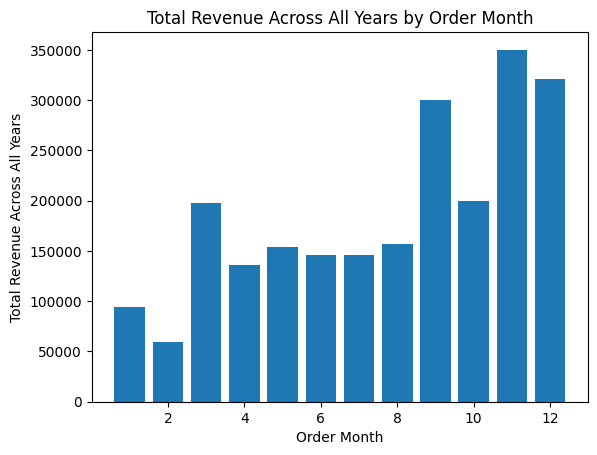

In [26]:
plt.bar(monthly_total_revenue['Order Month'], monthly_total_revenue['Total Revenue Across All Years'])
plt.xlabel('Order Month')
plt.ylabel('Total Revenue Across All Years')
plt.title('Total Revenue Across All Years by Order Month')
plt.show()

- Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
   - Trend component
   - Seasonal component
   - Residual/noise component

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set 'Month End Date' as index for decomposition
df_monthly_sales_indexed = df_monthly_sales.set_index('Month End Date')

# Apply time series decomposition
decomposition = seasonal_decompose(df_monthly_sales_indexed['Monthly Sales'], model='additive', period=12)

# Store the components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print('Trend Component (first 5 rows):')
trend.head()



Trend Component (first 5 rows):


,trend
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN


In [30]:
print('\nSeasonal Component (first 5 rows):')
seasonal.head()


Seasonal Component (first 5 rows):


,seasonal
Month End Date,
2015-01-31,-18307.338037
2015-02-28,-27368.402667
2015-03-31,1244.763035
2015-04-30,-10787.508768
2015-05-31,-4626.878630


In [31]:
print('\nResidual Component (first 5 rows):')
residual.head()


Residual Component (first 5 rows):


,resid
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN


-Plot all 4 components clearly on one figure
-Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?
- Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you
- Apply differencing if the series is non-stationary and re-test